In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:06<00:00, 10.2MB/s]

Extracting files...


Path to dataset files: /home/felipe/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [7]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RAMDOM_SEED = 42
labels = ["Normal", "Fraud"]

In [9]:
df = pd.read_csv(path + "/creditcard.csv", sep = ",")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Verificando valores e dados

In [11]:
df.isnull().values.any() #verificando se há valores nulos

np.False_

/tmp/ipykernel_33016/3272367729.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  contagem_classe = pd.value_counts(df['Class'], sort = True)


Text(0, 0.5, 'Frequencia')

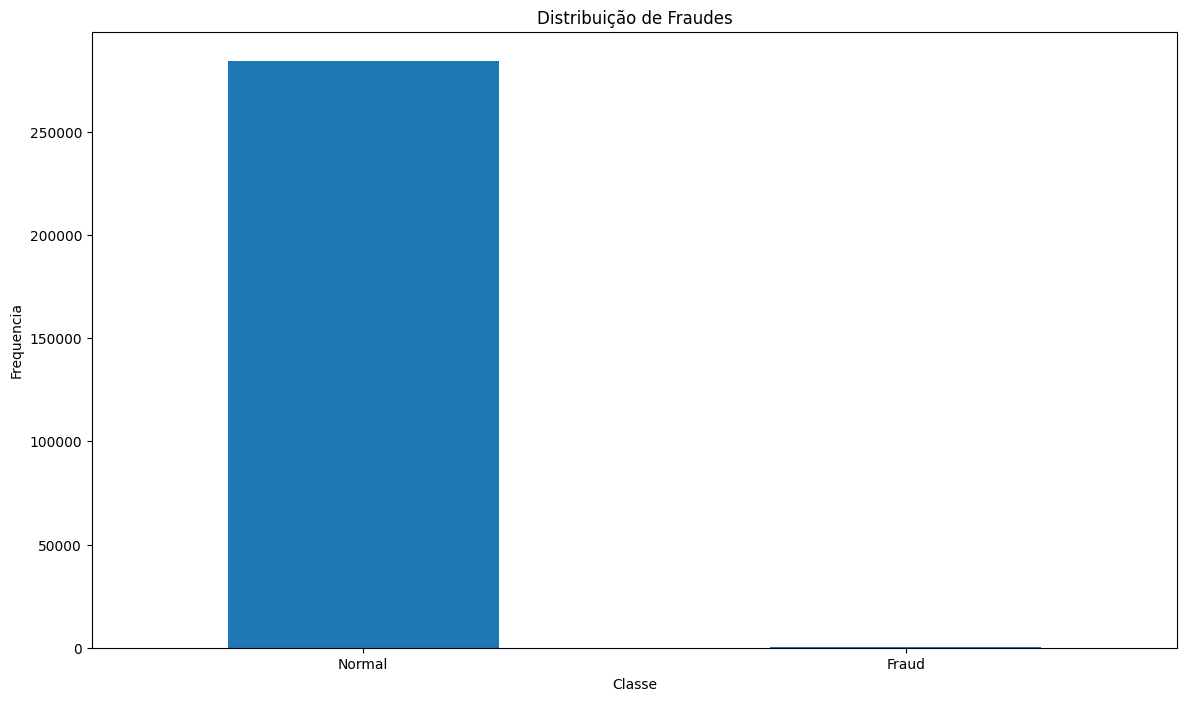

In [14]:
contagem_classe = pd.value_counts(df['Class'], sort = True)

contagem_classe.plot(kind = 'bar', rot=0)

plt.title("Distribuição de Fraudes")

plt.xticks(range(2), labels)

plt.xlabel("Classe")

plt.ylabel("Frequencia")

In [16]:
fraudes = df[df.Class == 1]
normal = df[df.Class == 0]

print(fraudes.shape, normal.shape)

(492, 31) (284315, 31)


In [19]:
fraudes['Amount'].describe() #Amount é a variável que representa o valor da transação. O valor máximo é 25691.16, o mínimo é 0.00 e a média é 88.34. A maioria das transações tem um valor baixo, mas há algumas transações com valores muito altos, o que pode indicar fraudes.

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [20]:
normal['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

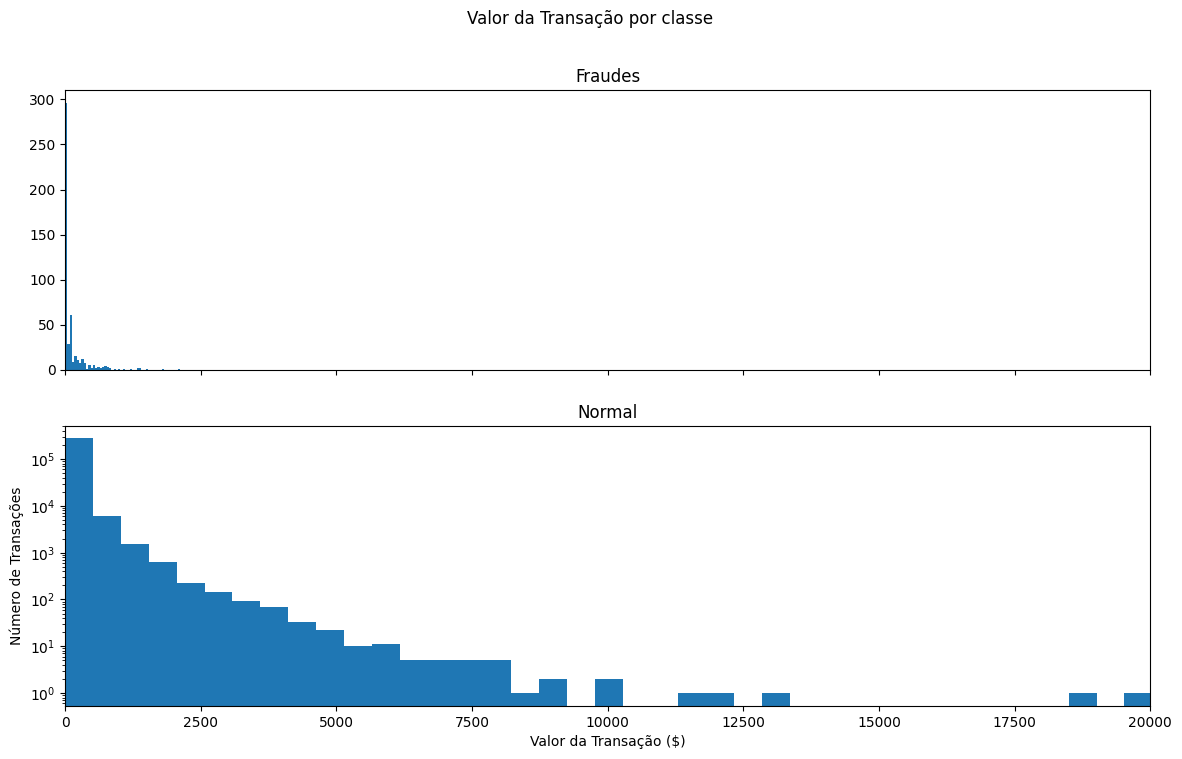

In [21]:
f, (ax1,ax2) = plt.subplots(2,1, sharex=True)
f.suptitle('Valor da Transação por classe')
bins = 50
ax1.hist(fraudes.Amount, bins = bins)
ax1.set_title('Fraudes')
ax2.hist(normal.Amount, bins = bins)
ax2.set_title('Normal')
plt.xlabel('Valor da Transação ($)')
plt.ylabel('Número de Transações')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show()

Ou seja, as transações fraudulentas estão em valores baixos comparados com as normais

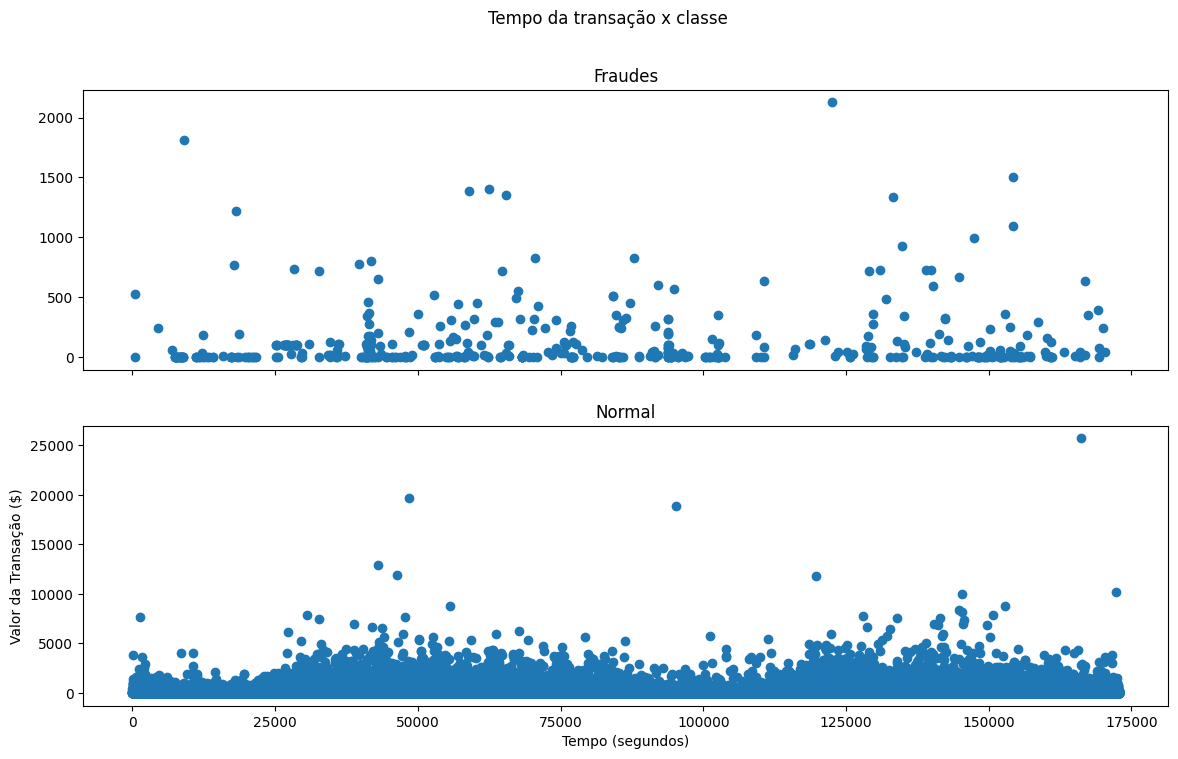

In [23]:
f, (ax1,ax2) = plt.subplots(2,1, sharex=True)
f.suptitle('Tempo da transação x classe')
ax1.scatter(fraudes.Time, fraudes.Amount)
ax1.set_title('Fraudes')
ax2.scatter(normal.Time, normal.Amount)
ax2.set_title('Normal')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Valor da Transação ($)')
plt.show()

In [25]:
data1 = df.sample(frac=0.1, random_state=RAMDOM_SEED)

data1.shape

(28481, 31)

In [26]:
df.shape

(284807, 31)

In [28]:
fraudes = data1[data1['Class'] == 1]
valido = data1[data1['Class'] == 0]

outlier_fraction = len(fraudes)/float(len(valido))

print(outlier_fraction)

0.001617724635132759


In [29]:
print("Fraudes: {}".format(len(fraudes)))
print("Valido: {}".format(len(valido)))

Fraudes: 46
Valido: 28435


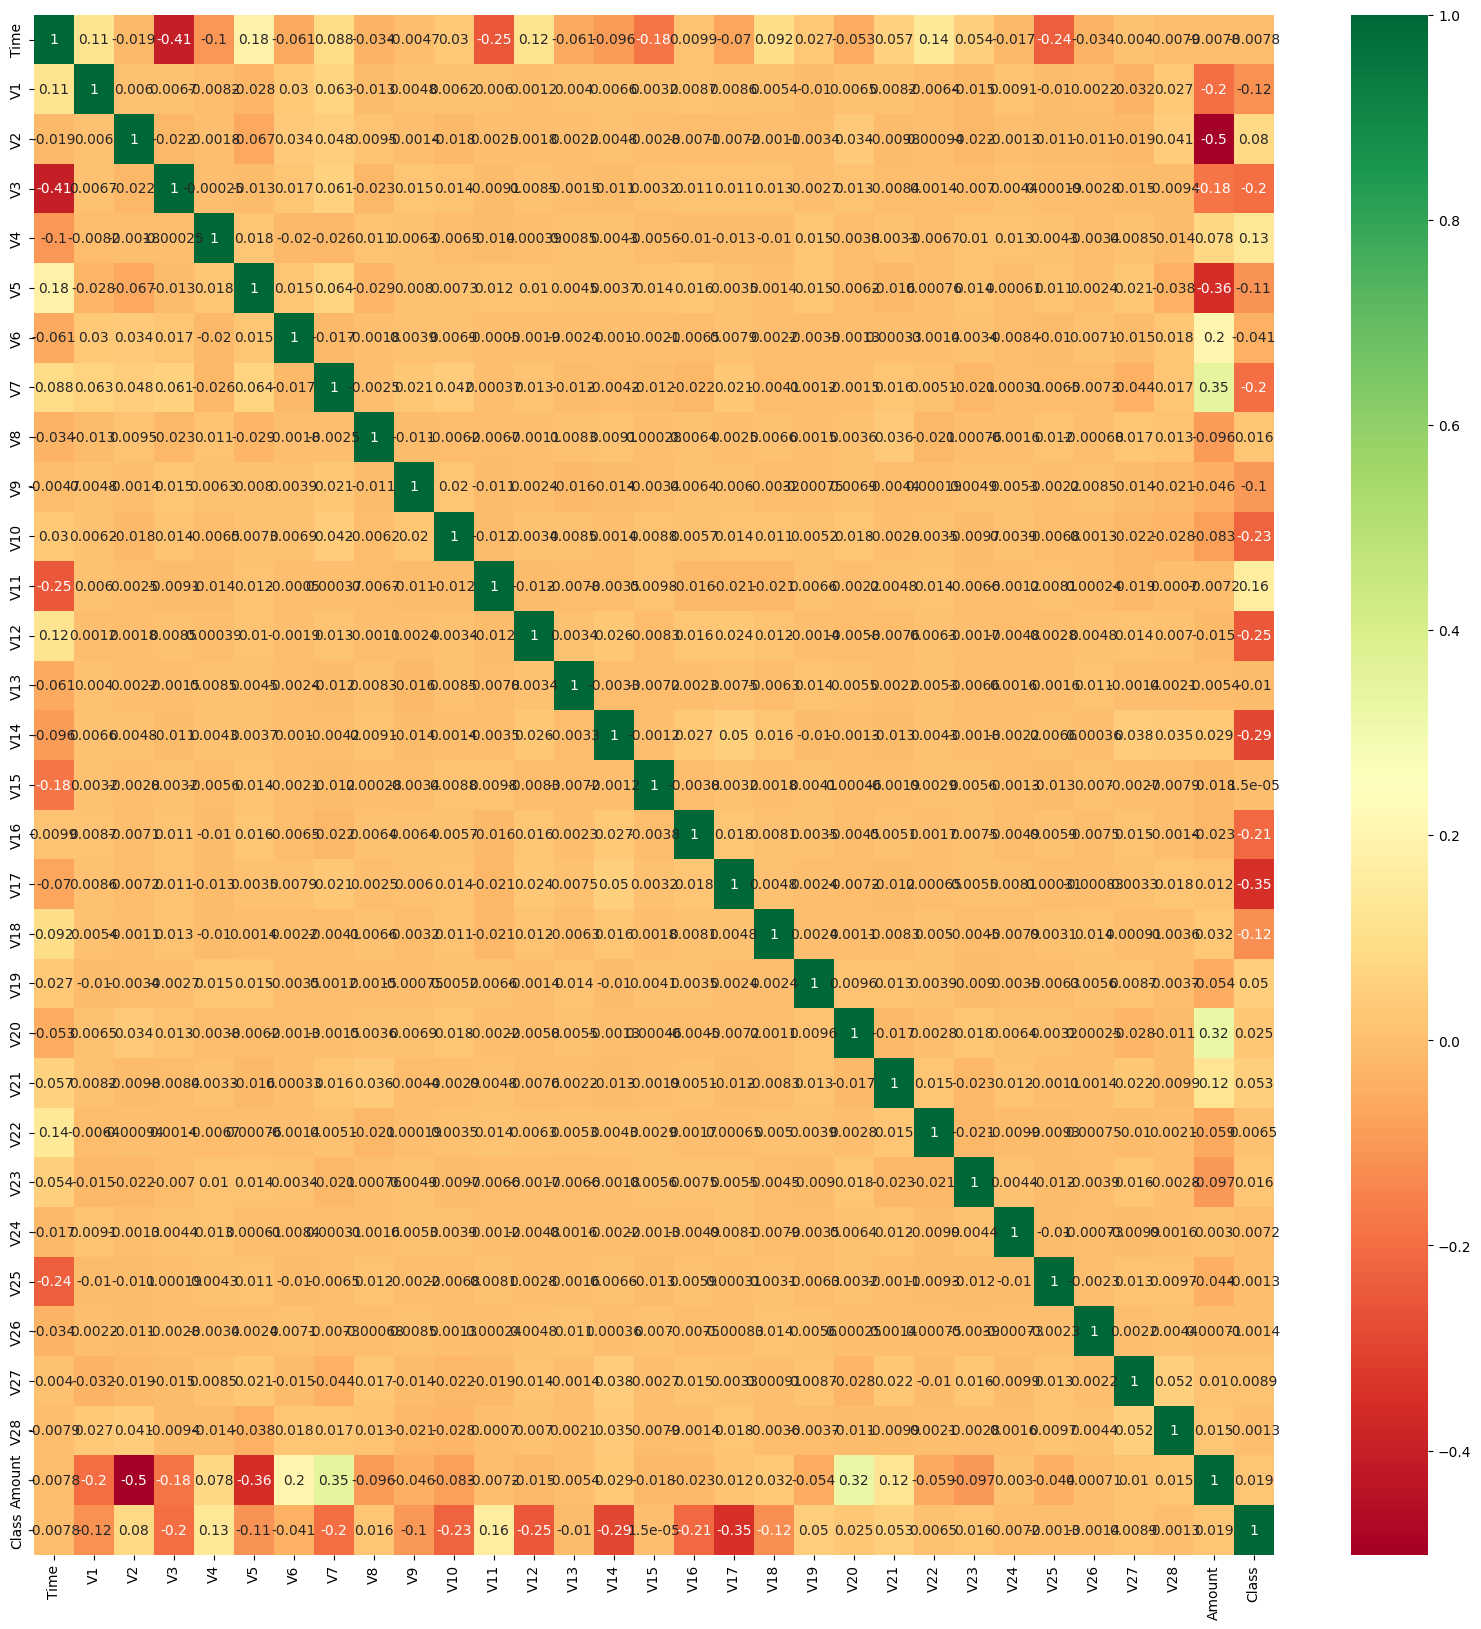

In [30]:
corrmat = data1.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))

g = sns.heatmap(data1[top_corr_features].corr(), annot=True, cmap="RdYlGn")

In [37]:
columns = data1.columns.tolist()
columns = [c for c in columns if c not in ["Class"]] #removendo a coluna de classe
target = "Class" #preciso armazenar a variável de classe em uma variável separada para treinar o modelo
state = np.random.RandomState(RAMDOM_SEED)
X = data1[columns]
Y = data1[target]
X_outliers = state.uniform(low=0, high=1, size=(X.shape[0], X.shape[1]))

print(X.shape)
print(Y.shape)

(28481, 30)
(28481,)


## Modelos de predição

### Isolation Forest
Qlgoritmo para anomalias não-supervisionadas. Ele tenta "isolar" os dados. Como as anomalias são poucas e diferentes, elas são isoladas muito mais rápido na estrutura de árvore do que os dados normais.

In [41]:
classificadores = {
    "Isolation Forest": IsolationForest(n_estimators=100, max_samples=len(X),
                                        contamination=outlier_fraction, random_state=state, verbose=0), #verbose=0 para não mostrar mensagens de treinamento
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=20, algorithm='auto',
                                               leaf_size=30, metric='minkowski', 
                                               p=2, metric_params=None, contamination=outlier_fraction),
    "One Class SVM": OneClassSVM(kernel='rbf', degree=3, gamma=0.1, nu=0.05,
                                 max_iter=-1)
}

In [42]:
type(classificadores)

dict

In [45]:
n_outliers = len(fraudes)
for i, (nome, classificador) in enumerate(classificadores.items()):
    #comparando os algoritmos/modelos
    if nome == "Local Outlier Factor":
        y_pred = classificador.fit_predict(X)
        scores_pred = classificador.negative_outlier_factor_
    elif nome == "One Class SVM":
        classificador.fit(X)
        y_pred = classificador.predict(X)
    else:
        classificador.fit(X)
        scores_pred = classificador.decision_function(X)
        y_pred = classificador.predict(X)
    #Vamos converter os rótulos de saída para 0 para as transações normais e 1 para as transações fraudulentas, para facilitar a comparação com os rótulos reais.
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1
    n_errors = (y_pred != Y).sum()

    print("{}: {}".format(nome, n_errors))
    print("Accuracy Score :")
    print(accuracy_score(Y, y_pred))
    print("Classification Report :")
    print(classification_report(Y, y_pred))

Isolation Forest: 65
Accuracy Score :
0.9977177767634563
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28435
           1       0.30      0.30      0.30        46

    accuracy                           1.00     28481
   macro avg       0.65      0.65      0.65     28481
weighted avg       1.00      1.00      1.00     28481

Local Outlier Factor: 91
Accuracy Score :
0.9968048874688389
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28435
           1       0.02      0.02      0.02        46

    accuracy                           1.00     28481
   macro avg       0.51      0.51      0.51     28481
weighted avg       1.00      1.00      1.00     28481

One Class SVM: 9526
Accuracy Score :
0.6655314069028475
Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.67      0.80  